In [3]:
import pandas as pd
import numpy as np
import csv
import random

import matplotlib.pyplot as plt


In [4]:
#download data
!gdown 1x3OX304PO-bonyooK4FKcRhyrTmT4kif
!unzip advertising.zip

Downloading...
From: https://drive.google.com/uc?id=1x3OX304PO-bonyooK4FKcRhyrTmT4kif
To: /content/advertising.zip
100% 1.90k/1.90k [00:00<00:00, 6.63MB/s]
Archive:  advertising.zip
  inflating: advertising.csv         


In [5]:
#discover data
DATA_PATH = "/content/advertising.csv"

data = pd.read_csv(DATA_PATH)

X = data.iloc[: ,:3]
y = data.iloc[:, -1]



In [6]:
def mean_normalization(X):
  # caculate
  N = len(X)

  max_value = np.max(X)
  min_value = np.min(X)
  mean_value = np.mean(X)

  #mean normalization
  X_b = (X -  mean_value) / (max_value - min_value)
  X_b = np.hstack((X_b, np.ones((N,1))))
  return X_b, max_value, min_value, mean_value

#Normalize data
X_b, maxi, mini, avg = mean_normalization(X)


In [ ]:
y

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9
...,...
195,7.6
196,14.0
197,14.8
198,25.5


In [ ]:
def stochastic_gradient_decent(X, y, lr = 0.01, n_epochs = 50):

  N = len(X)

  #initialize weighted and bias

  thetas = np.asarray([[1.16270837], [-0.81960489],
                        [1.39501033], [0.29763545]])
  losses = []

  for epoch in range(n_epochs):
    #get sample
    for i in range(N):
      xi = X[i:i+1]
      yi = y[i]
      #predict
      y_hat = xi.dot(thetas)

      #caculate Loss
      loss =  (yi - y_hat).T.dot((yi - y_hat))
      losses.append(loss[0])

      #compute gradient
      gradient = 2*xi.T.dot(y_hat - yi)

      #update param
      thetas = thetas - lr*gradient

  return losses, thetas


losses, thetas = stochastic_gradient_decent(X_b, y)



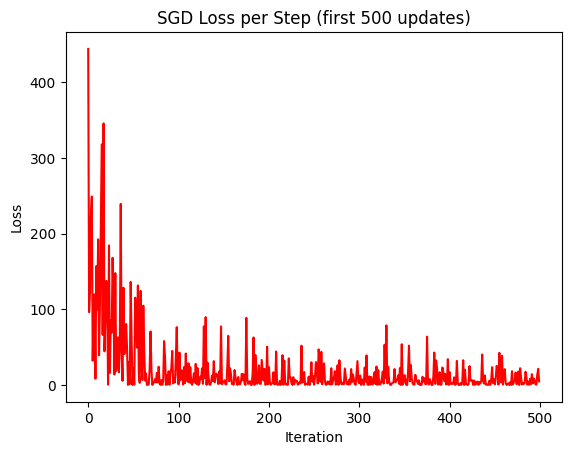

In [ ]:
x_axis = list(range(500))
plt.plot(x_axis, losses[:500], color="r")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("SGD Loss per Step (first 500 updates)")
plt.show()


In [30]:

def mini_batch_gradient_descent(X, y, mini_batch_size = 20, lr = 0.01, n_epochs = 50):

  N = len(X)
  #Initialize

  thetas = np.asarray([[1.16270837], [-0.81960489],
                        [1.39501033], [0.29763545]])
  losses = []

  for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(N)
    X = X[shuffled_indices]
    y = y[shuffled_indices]
  #Get samples
    for i in range(0, N, mini_batch_size):
      xi = X[i:i+mini_batch_size]
      yi = np.array(y[i:i+mini_batch_size])
      yi = yi.reshape(-1,1)

      m = len(xi)
      #Predict
      y_hat = xi.dot(thetas)

      #Loss
      loss = ((y_hat - yi).T.dot(y_hat - yi)) / m
      losses.append(loss[0])

      #Gradient

      gradient = (1/m)*2*xi.T.dot(y_hat - yi)

      #Update
      thetas = thetas - lr*gradient

  return thetas, losses

thetas, losses = mini_batch_gradient_descent(X_b, y)


array([26.32247505])

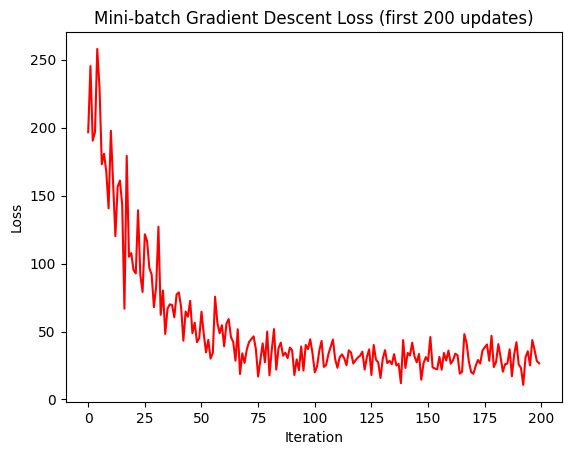

In [31]:
x_axis = list(range(200))

plt.plot(x_axis, losses[:200], color="r")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Mini-batch Gradient Descent Loss (first 200 updates)")
plt.show()

In [34]:
def batch_gradient_descent(X, y, lr = 0.01 , n_epochs = 100):

  N = len(X)

  y = np.array(y).reshape(-1, 1)

  #Initialize
  thetas = np.asarray([[1.16270837], [-0.81960489],
                        [1.39501033], [0.29763545]])
  losses = []

  for epoch in range(n_epochs):
    #predict
    y_hat = X.dot(thetas)

    #Loss

    loss = ((y_hat - y).T.dot(y_hat - y)) / N
    losses.append(loss[0])

    #Gradient
    gradient = 2 * X.T.dot(y_hat - y) / N

    #update
    thetas = thetas - lr*gradient

  return losses, thetas

losses, thetas = batch_gradient_descent(X_b, y)



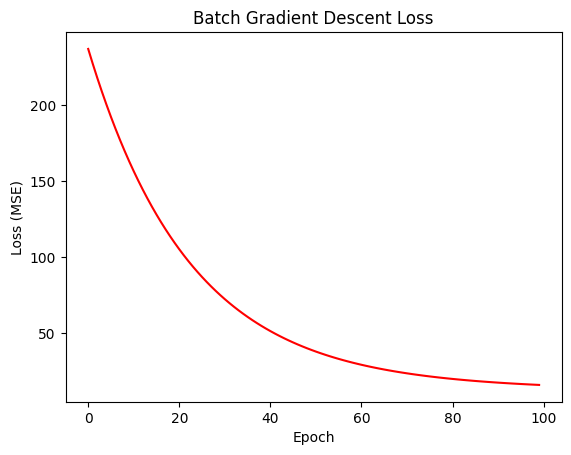

In [35]:
x_axis = list(range(100))
plt.plot(x_axis, losses[:100], color="r")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Batch Gradient Descent Loss")
plt.show()